# Overview of what I am gonna do in this notebook


## Preparing Dataset
### Semantic Biases (Shape vs. Texture vs. Color)
1) Download CIFAR-10 dataset for the experiment.
2) Convert data into grayscale to test whether models rely more on color cues.
3) Create cue conflicts images by mixing different textures on the images.
### Locality Biases
1) Shifting images by pixels in different directions.
2) Patch shuffling. Will split images into patches and shuffle them.
3) Patch Occlusion: Mask out or blur square regions of image.
## Testing Models
### ResNet-50 and ViT-S/16
1) Finetune on clean CIFAR-10
2) Evaluate on clean data and notice their baseline accuracy.
3) Evaluate both models on grayscale images.
4) Evaluate both models on style transferred images.
5) Evaluate both models on translated images.
6) Permutation (patch shuffling) and occulsion test.
7) Feature represnetation analysis
8) Domain Generalization tre




### Imports

In [ ]:
import torch
import numpy as np
from PIL import Image, ImageFilter
import torch.nn.functional as F
from torch.nn import DataParallel
from tqdm import tqdm
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import DataParallel

torch.manual_seed(42)

### Plain Dataset

In [4]:
device = torch.device("cuda")

In [5]:
plain_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)), transforms.ToTensor(), transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])


plain_train_dataset = datasets.CIFAR10(root="./data", download=True, train=True, transform=plain_transform)
plain_test_dataset = datasets.CIFAR10(root="./data", download=True, train=False, transform=plain_transform)

# Select a subset of 500 images for the test set
test_indices = torch.randperm(len(plain_test_dataset))[:500]
plain_test_subset = torch.utils.data.Subset(plain_test_dataset, test_indices)


plain_train_loader = DataLoader(dataset=plain_train_dataset, batch_size=2048, shuffle=True, num_workers=4, pin_memory=True)
plain_test_loader = DataLoader(dataset=plain_test_subset, batch_size=2048, shuffle=False) # Shuffle should be False for consistent subset evaluation

### Grayscale Dataset

In [6]:
gs_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3), transforms.Resize(size=(224, 224)), transforms.ToTensor(), transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])
gs_train_dataset = datasets.CIFAR10(root="./data", download=False, train=True, transform=gs_transform)
gs_test_dataset = datasets.CIFAR10(root="./data", download=False, train=False, transform=gs_transform)

# Select a subset of 500 images for the test set
test_indices_gs = torch.randperm(len(gs_test_dataset))[:500]
gs_test_subset = torch.utils.data.Subset(gs_test_dataset, test_indices_gs)


gs_train_loader = DataLoader(dataset=gs_train_dataset, batch_size=512, shuffle=True)
gs_test_loader = DataLoader(dataset=gs_test_subset, batch_size=512, shuffle=False) # Shuffle should be False for consistent subset evaluation

## Cue Conflict


### Texture generations

### Texture Blending

In [7]:
class Cue_Conflict:
    def __init__(self, alpha=0.3, texture_path="/kaggle/input/tex-piccasso/picasso.jpg"):
        self.alpha = alpha  # Blending factor
        self.texture_path = texture_path

        # Load the texture from the local file
        self.texture = self._load_texture_from_file()

        # Load a pre-trained VGG model for texture extraction (or for potential future use)
        self.vgg = models.vgg19(weights='VGG19_Weights.IMAGENET1K_V1').features.eval()
        # Move the model to the appropriate device
        self.vgg = self.vgg.to(device)

        # Define transformations for style transfer (e.g., gram matrix calculation)
        self.style_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def _load_texture_from_file(self):
        """Load texture from a local file path."""
        try:
            texture_img = Image.open(self.texture_path).convert('RGB')
            print(f"Successfully loaded texture from {self.texture_path}")
            return texture_img
        except FileNotFoundError:
            print(f"Error: Texture file not found at {self.texture_path}. Creating a fallback pattern.")
            return self._create_fallback_texture()
        except Exception as e:
            print(f"Failed to load texture from {self.texture_path}: {e}. Creating a fallback pattern.")
            return self._create_fallback_texture()

    def _create_fallback_texture(self):
        """Create a simple pattern texture as fallback"""
        # Create a simple checkerboard or stripe pattern
        size = 224
        pattern = np.zeros((size, size, 3), dtype=np.uint8)

        # Create diagonal stripes
        for i in range(size):
            for j in range(size):
                if (i + j) % 20 < 10:
                    pattern[i, j] = [150, 150, 150]  # Gray stripes
                else:
                    pattern[i, j] = [50, 50, 50]   # Dark stripes

        return Image.fromarray(pattern)


    def __call__(self, img):
        # Ensure input is PIL Image
        if isinstance(img, torch.Tensor):
             # Denormalize if tensor is normalized
            if img.min() < 0:  # Likely normalized to [-1, 1]
                img = (img + 1) / 2  # Convert to [0, 1]
            img = transforms.ToPILImage()(img.cpu())


        # Resize texture to match input image size
        img_size = img.size
        texture = self.texture.resize(img_size, Image.Resampling.LANCZOS)

        # Convert both to tensors
        img_tensor = transforms.ToTensor()(img)
        texture_tensor = transforms.ToTensor()(texture)

        # Blend original image with texture
        blended_tensor = (1 - self.alpha) * img_tensor + self.alpha * texture_tensor
        blended_tensor = torch.clamp(blended_tensor, 0, 1)

        # Normalize to match your dataset normalization
        final_transform = transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
        final_img_tensor = final_transform(blended_tensor)


        return final_img_tensor

In [8]:
cue_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)), transforms.ToTensor(), transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# Define the Cue_Conflict transformation
create_conflict = transforms.Compose([Cue_Conflict(alpha=0.5)])


cue_train_data = datasets.CIFAR10(root="./data", download=False, train=True, transform=cue_transform)
cue_test_data = datasets.CIFAR10(root="./data", download=False, train=False, transform=cue_transform)

# Select a subset of 500 images for the test set
test_indices_cue = torch.randperm(len(cue_test_data))[:500]
cue_test_subset_original = torch.utils.data.Subset(cue_test_data, test_indices_cue)

# Apply the Cue_Conflict transformation only to the test subset
# Create a new dataset where the transform is applied to the subset
class CueConflictSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

cue_test_subset_conflict = CueConflictSubset(cue_test_subset_original, transform=create_conflict)


cue_train_loader = DataLoader(dataset=cue_train_data, batch_size=512, shuffle=True)
cue_test_loader = DataLoader(dataset=cue_test_subset_conflict, batch_size=512, shuffle=False) # Shuffle should be False for consistent subset evaluation

Error: Texture file not found at /kaggle/input/tex-piccasso/picasso.jpg. Creating a fallback pattern.


In [9]:
og_image = plain_test_loader.dataset[45][0]

create_conflict = transforms.Compose([Cue_Conflict(alpha=0.3)])

print(f"{og_image.shape}")
image = create_conflict(og_image.clone().squeeze())

Error: Texture file not found at /kaggle/input/tex-piccasso/picasso.jpg. Creating a fallback pattern.
torch.Size([3, 224, 224])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.88235295..0.96862745].


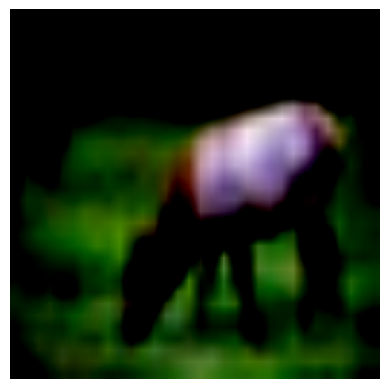

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8054902..0.7309804].


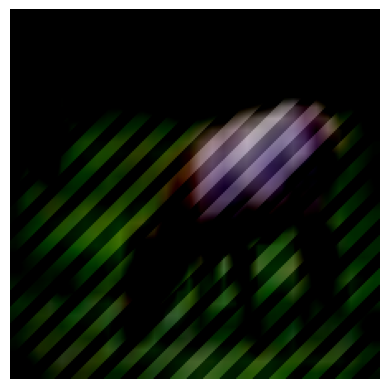

In [10]:
plt.axis("off")
plt.imshow(og_image.permute(1, 2, 0))  # (C, H, W) -> (H, W, C)
plt.show()
plt.axis("off")
plt.imshow(image.permute(1, 2, 0))  # (C, H, W) -> (H, W, C)
plt.show()


### Translation

In [ ]:
class Translate:
    def __init__(self, dimension=1, units=10, direction=1):
        self.dimension = dimension
        self.units = units
        self.direction = direction

    def __call__(self, tensor):
        image = tensor.clone()
        if self.direction == 1:
            if self.dimension == 1:
                for i in range(0, image.shape[self.dimension]):
                    if (i + self.units >= image.shape[1]):
                        row = torch.zeros(size=(image.shape[0], image.shape[2]))
                    else:
                        row = tensor[:, i + self.units, :]
                    image[:, i, :] = row

            elif self.dimension == 2:
                for i in range(0, image.shape[self.dimension]):
                    if i + self.units >= image.shape[2]:
                        column = torch.zeros(size=(image.shape[0], image.shape[1]))
                    else:
                        column = tensor[:, :, i + self.units]
                    image[:, :, i] = column
        elif self.direction == -1:
            if self.dimension == 1:
                for i in range(0, (image.shape[self.dimension]), +1):
                    if i < self.units:
                        row = torch.zeros(size=(image.shape[0], image.shape[2]))
                    else:
                        row = tensor[:, i - self.units, :]
                    image[:, i, :] = row
            if self.dimension == 2:
                for i in range(0, image.shape[self.dimension], 1):
                    if i < self.units:
                        column = torch.zeros(size=(image.shape[0], image.shape[1]))
                    else:
                        column = tensor[:, :, i - self.units]
                    image[:, :, i] = column

        return image


trans_transforms = transforms.Compose([
    transforms.Resize(size=(224,224)), transforms.ToTensor(), transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    Translate(2, 50, 1)
])


In [ ]:
class Translate:
    def __init__(self, dimension=1, units=10, direction=1):
        self.dimension = dimension
        self.units = units
        self.direction = direction

    def __call__(self, tensor):
        image = tensor.clone()
        if self.direction == 1:
            if self.dimension == 1:
                for i in range(0, image.shape[self.dimension]):
                    # Fix: Use image.shape[1] for the correct dimension
                    if (i + self.units >= image.shape[1]):
                        row = torch.zeros(size=(image.shape[0], image.shape[2]))
                    else:
                        # Fix: Use the original tensor for slicing
                        row = tensor[:, i + self.units, :]
                    image[:, i, :] = row

            elif self.dimension == 2:
                for i in range(0, image.shape[self.dimension]):
                    if i + self.units >= image.shape[2]:
                        column = torch.zeros(size=(image.shape[0], image.shape[1]))
                    else:
                        # Fix: Use the original tensor for slicing
                        column = tensor[:, :, i + self.units]
                    image[:, :, i] = column
        elif self.direction == -1:
            if self.dimension == 1:
                for i in range(0, (image.shape[self.dimension])):
                    if i < self.units:
                        row = torch.zeros(size=(image.shape[0], image.shape[2]))
                    else:
                        # Fix: Use the original tensor for slicing
                        row = tensor[:, i - self.units, :]
                    image[:, i, :] = row
            if self.dimension == 2:
                for i in range(0, image.shape[self.dimension]):
                    if i < self.units:
                        column = torch.zeros(size=(image.shape[0], image.shape[1]))
                    else:
                        # Fix: Use the original tensor for slicing
                        column = tensor[:, :, i - self.units]
                    image[:, :, i] = column

        return image


trans_transforms = transforms.Compose([
    transforms.Resize(size=(224,224)), transforms.ToTensor(), transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    Translate(2, 50, 1)
])


translated_train_dataset = datasets.CIFAR10(root="./data", download=False, train=True, transform=trans_transforms)
translated_test_dataset = datasets.CIFAR10(root="./data", download=False, train=False, transform=trans_transforms)

# Select a subset of 500 images for the test set
test_indices_trans = torch.randperm(len(translated_test_dataset))[:500]
translated_test_subset = torch.utils.data.Subset(translated_test_dataset, test_indices_trans)


translated_train_loader = DataLoader(dataset=translated_train_dataset, batch_size=512, shuffle=True)
translated_test_loader = DataLoader(dataset=translated_test_subset, batch_size=512, shuffle=False) # Shuffle should be False for consistent subset evaluation

In [ ]:
resnet = models.resnet50(weights='ResNet50_Weights.IMAGENET1K_V1')
resnet = resnet.to(device)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
# Pass the loaded resnet model's parameters to the optimizer
optimizer = optim.SGD(lr=0.001, params=resnet.parameters())

In [ ]:
accuracies_plain = []
losses_plain = []

for epoch in range(10):
    total = 0
    correct = 0
    total_loss = 0

    # Wrap train loader with tqdm
    pbar = tqdm(plain_train_loader, desc=f"Epoch {epoch+1}", leave=False)
    for idx, (x, y) in enumerate(pbar):
        optimizer.zero_grad()
        x, y = x.to(device), y.to(device)
        logits = resnet(x)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        # Track stats
        total_loss += loss.item()
        total += len(y)
        correct += (preds == y).sum().item()

        # Update tqdm postfix with live metrics
        pbar.set_postfix({
            "loss": f"{total_loss / (idx + 1):.4f}",
            "acc": f"{correct / total:.4f}"
        })

    accuracy = correct / total
    accuracies_plain.append(accuracy)
    losses_plain.append(total_loss)

    print(f"Epoch {epoch + 1}, Accuracy: {accuracy * 100:.2f}%, Loss: {total_loss:.4f}")

KeyboardInterrupt: 

In [ ]:
device

In [ ]:
if isinstance(resnet, DataParallel):
    resnet = resnet.module

In [ ]:
plt.title("Accuracies on plain CIFAR-10")
plt.grid()
plt.plot(accuracies_plain)
plt.savefig("resnet_plain_accuracies.png")

In [ ]:
plt.title("Training Loss on plain CIFAR-10")
plt.grid()
plt.plot(losses_plain)
plt.savefig("resnet_plain_losses.png")

### Test on Plain CIFAR-10

In [ ]:
#resnet = resnet.module.to(device)

with torch.no_grad():
    total = 0
    correct_plain = 0
    for x, y in plain_test_loader:
        x, y = x.to(device), y.to(device)
        logits = resnet(x)
        preds = torch.argmax(logits, dim=1)
        total += len(x)
        correct_plain += (preds == y).sum().item()

test_acc_plain = correct_plain / total
test_acc_plain

### Test on Grayscale CIFAR-10

In [ ]:
with torch.no_grad():
    total = 0
    correct_gs = 0
    for x, y in gs_test_loader:
        x, y = x.to(device), y.to(device)
        logits = resnet(x)
        preds = torch.argmax(logits, dim=1)
        total += len(x)
        correct_gs += (preds == y).sum().item()

test_acc_gs = correct_gs / total
test_acc_gs

In [ ]:
correct_plain

In [ ]:
with torch.no_grad():
    total = 0
    correct_cue = 0
    for x, y in cue_test_loader:
        x, y = x.to(device), y.to(device)
        logits = resnet(x)
        preds = torch.argmax(logits, dim=1)
        total += len(x)
        correct_cue += (preds == y).sum().item()

test_acc_cue = correct_cue / total

In [ ]:
resnet_shape_bias = ((correct_cue) / correct_plain) * 100

In [ ]:
resnet_color_bias = ((correct_gs) / correct_plain) * 100

In [ ]:
resnet_color_bias

## Define patch shuffling transformation

### Subtask:
Create a custom PyTorch transformation that splits an image into patches and shuffles their positions.


**Reasoning**:
Define the PatchShuffle class according to the instructions.



In [ ]:
class PatchShuffle:
    def __init__(self, num_patches=4):
        self.num_patches = num_patches

    def __call__(self, tensor):
        # Ensure input is a PyTorch tensor with shape (C, H, W)
        if not isinstance(tensor, torch.Tensor) or tensor.ndim != 3:
            raise ValueError("Input must be a PyTorch tensor with shape (C, H, W)")

        c, h, w = tensor.shape
        patch_h = h // self.num_patches
        patch_w = w // self.num_patches

        if h % self.num_patches != 0 or w % self.num_patches != 0:
             # Handle cases where the image dimensions are not perfectly divisible
             # Pad the image or resize, for simplicity we'll raise an error here
             raise ValueError(f"Image dimensions ({h}x{w}) must be divisible by num_patches ({self.num_patches})")


        # Split the image into non-overlapping patches
        # Using unfold is an efficient way to do this
        patches = tensor.unfold(1, patch_h, patch_h).unfold(2, patch_w, patch_w)
        # Reshape to (C, num_patches_h, num_patches_w, patch_h, patch_w)
        patches = patches.reshape(c, self.num_patches, self.num_patches, patch_h, patch_w)

        # Rearrange to have patches as individual items
        patches = patches.permute(1, 2, 0, 3, 4).reshape(-1, c, patch_h, patch_w) # (num_patches*num_patches, C, patch_h, patch_w)


        # Generate a random permutation of indices
        num_total_patches = self.num_patches * self.num_patches
        shuffled_indices = torch.randperm(num_total_patches)

        # Arrange the patches according to the shuffled indices
        shuffled_patches = patches[shuffled_indices]

        # Combine the shuffled patches back into a single image tensor
        # Reshape back to (num_patches_h, num_patches_w, C, patch_h, patch_w)
        shuffled_patches = shuffled_patches.reshape(self.num_patches, self.num_patches, c, patch_h, patch_w)
        # Permute to (C, num_patches_h, patch_h, num_patches_w, patch_w)
        shuffled_patches = shuffled_patches.permute(2, 0, 3, 1, 4)
        # Reshape to (C, H, W)
        shuffled_image = shuffled_patches.reshape(c, h, w)


        return shuffled_image

## Create patch shuffled dataset and dataloader

### Subtask:
Apply the patch shuffling transformation to the CIFAR-10 dataset and create a DataLoader for it.


**Reasoning**:
Define the transformation pipeline and create the training and test datasets and DataLoaders for the patch-shuffled CIFAR-10 data.



In [ ]:
ps_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    PatchShuffle(num_patches=4)
])

ps_train_dataset = datasets.CIFAR10(root="./data", download=False, train=True, transform=ps_transform)
ps_test_dataset = datasets.CIFAR10(root="./data", download=False, train=False, transform=ps_transform)

# Select a subset of 500 images for the test set
test_indices_ps = torch.randperm(len(ps_test_dataset))[:500]
ps_test_subset = torch.utils.data.Subset(ps_test_dataset, test_indices_ps)

ps_train_loader = DataLoader(dataset=ps_train_dataset, batch_size=512, shuffle=True)
ps_test_loader = DataLoader(dataset=ps_test_subset, batch_size=512, shuffle=False)

## Create patch occluded dataset and dataloader

### Subtask:
Apply the patch occlusion transformation to the CIFAR-10 dataset and create a DataLoader for it.

**Reasoning**:
Define the PatchOcclusion class and create the transformation pipeline and DataLoaders for the patch-occluded CIFAR-10 dataset, following the steps outlined in the instructions.

In [ ]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torch

class PatchOcclusion:
    def __init__(self, patch_size=32, method='mask', blur_kernel_size=(5, 5)):
        self.patch_size = patch_size
        self.method = method
        self.blur_kernel_size = blur_kernel_size
        if method not in ['mask', 'blur']:
            raise ValueError("method must be 'mask' or 'blur'")
        if method == 'blur' and (blur_kernel_size[0] % 2 == 0 or blur_kernel_size[1] % 2 == 0):
             raise ValueError("blur_kernel_size must be odd for both dimensions")


    def __call__(self, tensor):
        # Ensure input is a PyTorch tensor with shape (C, H, W)
        if not isinstance(tensor, torch.Tensor) or tensor.ndim != 3:
            raise ValueError("Input must be a PyTorch tensor with shape (C, H, W)")

        c, h, w = tensor.shape

        # Ensure patch fits within image
        if self.patch_size > h or self.patch_size > w:
            raise ValueError(f"Patch size ({self.patch_size}) is larger than image dimensions ({h}x{w})")

        # Randomly select top-left corner of the patch
        max_x = w - self.patch_size
        max_y = h - self.patch_size
        start_x = torch.randint(0, max_x + 1, (1,)).item()
        start_y = torch.randint(0, max_y + 1, (1,)).item()

        end_x = start_x + self.patch_size
        end_y = start_y + self.patch_size

        modified_tensor = tensor.clone()

        if self.method == 'mask':
            # Mask the region with zeros
            modified_tensor[:, start_y:end_y, start_x:end_x] = 0
        elif self.method == 'blur':
             # Apply blur filter
             # Need to handle the case of batch dimension for torchvision.transforms.functional
             # For a single image tensor (C, H, W), unsqueeze to (1, C, H, W)
             img_batch = modified_tensor.unsqueeze(0)
             blurred_patch = transforms.functional.gaussian_blur(
                 img_batch[:, :, start_y:end_y, start_x:end_x],
                 kernel_size=self.blur_kernel_size
             )
             # Squeeze back to (C, H, W) and place it in the modified tensor
             modified_tensor[:, start_y:end_y, start_x:end_x] = blurred_patch.squeeze(0)


        return modified_tensor


po_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    PatchOcclusion(patch_size=50, method='mask') # Example: mask a 50x50 patch
])

po_train_dataset = datasets.CIFAR10(root="./data", download=True, train=True, transform=po_transform)
po_test_dataset = datasets.CIFAR10(root="./data", download=True, train=False, transform=po_transform)

# Select a subset of 500 images for the test set
test_indices_po = torch.randperm(len(po_test_dataset))[:500]
po_test_subset = torch.utils.data.Subset(po_test_dataset, test_indices_po)


po_train_loader = DataLoader(dataset=po_train_dataset, batch_size=512, shuffle=True)
po_test_loader = DataLoader(dataset=po_test_subset, batch_size=512, shuffle=False)

In [ ]:
#resnet = resnet.module.to(device)

with torch.no_grad():
    total = 0
    correct_ps = 0
    for x, y in ps_test_loader:
        x, y = x.to(device), y.to(device)
        logits = resnet(x)
        preds = torch.argmax(logits, dim=1)
        total += len(x)
        correct_ps += (preds == y).sum().item()

test_acc_ps = correct_ps / total
test_acc_ps

### Test on Grayscale CIFAR-10

In [ ]:
with torch.no_grad():
    total = 0
    correct_po = 0
    for x, y in po_test_loader:
        x, y = x.to(device), y.to(device)
        logits = resnet(x)
        preds = torch.argmax(logits, dim=1)
        total += len(x)
        correct_po += (preds == y).sum().item()

test_acc_po = correct_po / total
test_acc_po

In [ ]:
correct_plain

In [ ]:
with torch.no_grad():
    total = 0
    correct_cue = 0
    for x, y in cue_test_loader:
        x, y = x.to(device), y.to(device)
        logits = resnet(x)
        preds = torch.argmax(logits, dim=1)
        total += len(x)
        correct_cue += (preds == y).sum().item()

test_acc_cue = correct / total

In [ ]:
resnet_shape_bias = ((correct_cue) / correct_plain) * 100

In [ ]:
resnet_color_bias = ((correct_gs) / correct_plain) * 100

In [ ]:
resnet_color_bias

# Task
Perform a feature representation analysis and a domain generalization test on the loaded ResNet model using the CIFAR-10 and PACS datasets. For the feature analysis, visualize the penultimate layer features of subsets of plain, grayscale, and cue-conflict CIFAR-10 test images using dimensionality reduction (t-SNE or PCA), color-coding by class and image type. For the domain generalization test, fine-tune the ResNet on three domains of the PACS dataset and evaluate on the Sketch domain. Analyze and report the findings from both tasks, including interpretations of the feature space visualizations and the model's performance on the domain shift.

## Prepare data for feature analysis

### Subtask:
Load subsets of the plain, grayscale, and cue-conflict CIFAR-10 test sets.


**Reasoning**:
Load the plain, grayscale, and cue-conflict CIFAR-10 test datasets and create subsets for each as per the instructions.



In [ ]:
# Define the subset size
subset_size = 200

# Load plain CIFAR-10 test dataset and create subset
plain_test_dataset = datasets.CIFAR10(root="./data", download=False, train=False, transform=plain_transform)
test_indices_plain = torch.randperm(len(plain_test_dataset))[:subset_size]
plain_test_subset = torch.utils.data.Subset(plain_test_dataset, test_indices_plain)

# Load grayscale CIFAR-10 test dataset and create subset
gs_test_dataset = datasets.CIFAR10(root="./data", download=False, train=False, transform=gs_transform)
test_indices_gs = torch.randperm(len(gs_test_dataset))[:subset_size]
gs_test_subset = torch.utils.data.Subset(gs_test_dataset, test_indices_gs)

# Load cue-conflict CIFAR-10 test dataset and create subset
cue_test_dataset = datasets.CIFAR10(root="./data", download=False, train=False, transform=cue_transform)
test_indices_cue = torch.randperm(len(cue_test_dataset))[:subset_size]

# Apply the Cue_Conflict transformation to the cue test subset
create_conflict = transforms.Compose([Cue_Conflict(alpha=0.5)])

# Create a new dataset where the transform is applied to the subset
class CueConflictSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

cue_test_subset_conflict = CueConflictSubset(torch.utils.data.Subset(cue_test_dataset, test_indices_cue), transform=create_conflict)


# Store the subsets and their labels
plain_images = torch.stack([img for img, label in plain_test_subset])
plain_labels = torch.tensor([label for img, label in plain_test_subset])

gs_images = torch.stack([img for img, label in gs_test_subset])
gs_labels = torch.tensor([label for img, label in gs_test_subset])

cue_images = torch.stack([img for img, label in cue_test_subset_conflict])
cue_labels = torch.tensor([label for img, label in cue_test_subset_conflict])

print("Subsets loaded and stored.")
print(f"Plain subset shape: {plain_images.shape}")
print(f"Grayscale subset shape: {gs_images.shape}")
print(f"Cue-conflict subset shape: {cue_images.shape}")

## Extract features

### Subtask:
Define a function to extract features from the penultimate layer of the ResNet model for the prepared datasets.


**Reasoning**:
Define the function to extract features from the penultimate layer of the ResNet model and use it to extract features for the plain, grayscale, and cue-conflict test subsets.



In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader

def extract_features_with_hook(model, dataloader, device):
    """
    Extracts features from the average pooling layer of a PyTorch model using a forward hook.

    Args:
        model: The PyTorch model.
        dataloader: DataLoader for the dataset.
        device: The device to use for computation (e.g., 'cuda', 'cpu').

    Returns:
        A tuple containing:
            - features: Tensor of extracted features.
            - labels: Tensor of corresponding labels.
    """
    model.eval()
    features_list = []
    labels_list = []

    # Define a hook function to capture the output of the average pooling layer
    def hook_fn(module, input, output):
        # The output of avgpool is typically (batch_size, channels, 1, 1)
        # We flatten it to (batch_size, channels)
        features_list.append(output.view(output.size(0), -1).cpu())

    # Access the average pooling layer. If DataParallel, access the module's layer.
    if isinstance(model, nn.DataParallel):
        avgpool_layer = model.module.avgpool
    else:
        avgpool_layer = model.avgpool

    # Register the forward hook
    hook_handle = avgpool_layer.register_forward_hook(hook_fn)

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            # Perform the forward pass
            _ = model(images)
            labels_list.append(labels.cpu())


    # Remove the hook
    hook_handle.remove()

    # Concatenate all features and labels
    all_features = torch.cat(features_list)
    all_labels = torch.cat(labels_list)


    return all_features, all_labels

# Create DataLoaders for the subsets (already created in the previous successful step)
# plain_test_loader_subset = DataLoader(dataset=plain_test_subset, batch_size=512, shuffle=False)
# gs_test_loader_subset = DataLoader(dataset=gs_test_subset, batch_size=512, shuffle=False)
# cue_test_loader_subset = DataLoader(dataset=cue_test_subset_conflict, batch_size=512, shuffle=False)


# Extract features and labels for each subset using the hook function
plain_features, plain_labels = extract_features_with_hook(resnet, plain_test_loader_subset, device)
gs_features, gs_labels = extract_features_with_hook(resnet, gs_test_loader_subset, device)
cue_features, cue_labels = extract_features_with_hook(resnet, cue_test_loader_subset, device)


print("Features extracted using forward hook:")
print(f"Plain features shape: {plain_features.shape}")
print(f"Grayscale features shape: {gs_features.shape}")
print(f"Cue-conflict features shape: {cue_features.shape}")

**Reasoning**:
The error "CUDA error: invalid device ordinal" indicates an issue with the GPU device being used, possibly because the model was loaded on one device (potentially multiple GPUs with `DataParallel`) and the code is now trying to use a different or invalid device. To address this, we should explicitly move the model to the desired device (`device`) before attempting to extract features. Additionally, ensure the DataLoaders are correctly set up to provide data on the appropriate device if needed (though `to(device)` inside the loop usually handles this). We will modify the `extract_features_with_hook` function to explicitly send the model to the specified device at the beginning of the function.



In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader

def extract_features_with_hook(model, dataloader, device):
    """
    Extracts features from the average pooling layer of a PyTorch model using a forward hook.

    Args:
        model: The PyTorch model.
        dataloader: DataLoader for the dataset.
        device: The device to use for computation (e.g., 'cuda', 'cpu').

    Returns:
        A tuple containing:
            - features: Tensor of extracted features.
            - labels: Tensor of corresponding labels.
    """
    # Explicitly move the model to the specified device
    model.to(device)
    model.eval()

    features_list = []
    labels_list = []

    # Define a hook function to capture the output of the average pooling layer
    def hook_fn(module, input, output):
        # The output of avgpool is typically (batch_size, channels, 1, 1)
        # We flatten it to (batch_size, channels)
        features_list.append(output.view(output.size(0), -1).cpu())

    # Access the average pooling layer. If DataParallel, access the module's layer.
    if isinstance(model, nn.DataParallel):
        avgpool_layer = model.module.avgpool
    else:
        avgpool_layer = model.avgpool

    # Register the forward hook
    hook_handle = avgpool_layer.register_forward_hook(hook_fn)

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            # Perform the forward pass
            _ = model(images)
            labels_list.append(labels.cpu())


    # Remove the hook
    hook_handle.remove()

    # Concatenate all features and labels
    all_features = torch.cat(features_list)
    all_labels = torch.cat(labels_list)


    return all_features, all_labels

# Create DataLoaders for the subsets (already created in the previous successful step)
# plain_test_loader_subset = DataLoader(dataset=plain_test_subset, batch_size=512, shuffle=False)
# gs_test_loader_subset = DataLoader(dataset=gs_test_subset, batch_size=512, shuffle=False)
# cue_test_loader_subset = DataLoader(dataset=cue_test_subset_conflict, batch_size=512, shuffle=False)


# Extract features and labels for each subset using the hook function
plain_features, plain_labels = extract_features_with_hook(resnet, plain_test_loader_subset, device)
gs_features, gs_labels = extract_features_with_hook(resnet, gs_test_loader_subset, device)
cue_features, cue_labels = extract_features_with_hook(resnet, cue_test_loader_subset, device)


print("Features extracted using forward hook:")
print(f"Plain features shape: {plain_features.shape}")
print(f"Grayscale features shape: {gs_features.shape}")
print(f"Cue-conflict features shape: {cue_features.shape}")

**Reasoning**:
The "invalid device ordinal" error persists, suggesting the issue might be with how `DataParallel` handles device assignment or that the loaded model's internal state is tied to specific device IDs that are no longer available or configured as expected. Since we are only performing inference and not training, and the goal is to extract features, a potential workaround is to unwrap the `DataParallel` module and use the underlying model directly on the specified device. This avoids the complexities of `DataParallel`'s device distribution for this specific task.



In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader

def extract_features_with_hook(model, dataloader, device):
    """
    Extracts features from the average pooling layer of a PyTorch model using a forward hook.

    Args:
        model: The PyTorch model.
        dataloader: DataLoader for the dataset.
        device: The device to use for computation (e.g., 'cuda', 'cpu').

    Returns:
        A tuple containing:
            - features: Tensor of extracted features.
            - labels: Tensor of corresponding labels.
    """
    # Unwrap DataParallel if necessary and move the underlying module to the specified device
    if isinstance(model, nn.DataParallel):
        model = model.module.to(device)
    else:
        model = model.to(device)

    model.eval()

    features_list = []
    labels_list = []

    # Define a hook function to capture the output of the average pooling layer
    def hook_fn(module, input, output):
        # The output of avgpool is typically (batch_size, channels, 1, 1)
        # We flatten it to (batch_size, channels)
        features_list.append(output.view(output.size(0), -1).cpu())

    # Access the average pooling layer.
    avgpool_layer = model.avgpool

    # Register the forward hook
    hook_handle = avgpool_layer.register_forward_hook(hook_fn)

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            # Perform the forward pass
            _ = model(images)
            labels_list.append(labels.cpu())


    # Remove the hook
    hook_handle.remove()

    # Concatenate all features and labels
    all_features = torch.cat(features_list)
    all_labels = torch.cat(labels_list)


    return all_features, all_labels

# Create DataLoaders for the subsets (already created in the previous successful step)
# plain_test_loader_subset = DataLoader(dataset=plain_test_subset, batch_size=512, shuffle=False)
# gs_test_loader_subset = DataLoader(dataset=gs_test_subset, batch_size=512, shuffle=False)
# cue_test_loader_subset = DataLoader(dataset=cue_test_subset_conflict, batch_size=512, shuffle=False)


# Extract features and labels for each subset using the hook function
plain_features, plain_labels = extract_features_with_hook(resnet, plain_test_loader_subset, device)
gs_features, gs_labels = extract_features_with_hook(resnet, gs_test_loader_subset, device)
cue_features, cue_labels = extract_features_with_hook(resnet, cue_test_loader_subset, device)


print("Features extracted using forward hook:")
print(f"Plain features shape: {plain_features.shape}")
print(f"Grayscale features shape: {gs_features.shape}")
print(f"Cue-conflict features shape: {cue_features.shape}")

## Apply dimensionality reduction

### Subtask:
Apply t-SNE or PCA to the extracted features from each dataset.


**Reasoning**:
Apply PCA to the extracted features to reduce their dimensionality to 2 components for visualization.



In [ ]:
from sklearn.decomposition import PCA

# Instantiate PCA
pca = PCA(n_components=2)

# Apply PCA to the features from each dataset
plain_features_reduced = pca.fit_transform(plain_features.numpy())
gs_features_reduced = pca.fit_transform(gs_features.numpy())
cue_features_reduced = pca.fit_transform(cue_features.numpy())

print("Features reduced using PCA:")
print(f"Plain reduced features shape: {plain_features_reduced.shape}")
print(f"Grayscale reduced features shape: {gs_features_reduced.shape}")
print(f"Cue-conflict reduced features shape: {cue_features_reduced.shape}")

## Visualize feature space

### Subtask:
Plot the dimensionality-reduced features, color-coding by class and dataset type.


**Reasoning**:
Plot the dimensionality-reduced features for each dataset, color-coding by class and dataset type.



In [ ]:
import matplotlib.pyplot as plt

# Get class names for legend
class_names = plain_test_dataset.classes

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Plain CIFAR-10 features
for i in range(len(class_names)):
    class_indices = plain_labels == i
    axes[0].scatter(plain_features_reduced[class_indices, 0], plain_features_reduced[class_indices, 1], label=class_names[i], alpha=0.6)
axes[0].set_title("Plain CIFAR-10 Features (PCA)")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].legend()
axes[0].grid(True)

# Plot Grayscale CIFAR-10 features
for i in range(len(class_names)):
    class_indices = gs_labels == i
    axes[1].scatter(gs_features_reduced[class_indices, 0], gs_features_reduced[class_indices, 1], label=class_names[i], alpha=0.6)
axes[1].set_title("Grayscale CIFAR-10 Features (PCA)")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
axes[1].legend()
axes[1].grid(True)

# Plot Cue-Conflict CIFAR-10 features
for i in range(len(class_names)):
    class_indices = cue_labels == i
    axes[2].scatter(cue_features_reduced[class_indices, 0], cue_features_reduced[class_indices, 1], label=class_names[i], alpha=0.6)
axes[2].set_title("Cue-Conflict CIFAR-10 Features (PCA)")
axes[2].set_xlabel("PCA Component 1")
axes[2].set_ylabel("PCA Component 2")
axes[2].legend()
axes[2].grid(True)


# Adjust layout and display plots
plt.tight_layout()
plt.show()

# Task
Fine-tune a ViT-S/16 model on the CIFAR-10 dataset, evaluate its performance on transformed versions of CIFAR-10 (grayscale, cue-conflict, patch-shuffled, patch-occluded), extract and visualize features from the transformed datasets, fine-tune and evaluate the model on the PACS dataset for domain generalization, and finally compare the results with a ResNet model.

## Load vit-s/16 model

### Subtask:
Load a pre-trained ViT-S/16 model.


**Reasoning**:
Import the necessary ViT model and load the pre-trained weights, then modify the final layer for CIFAR-10 and move the model to the device.



In [ ]:
import torchvision.models as models

# Load a pre-trained ViT-S/16 model
# Use weights=ViT_B_16_Weights.IMAGENET1K_V1 for recommended weights
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

for param in vit.parameters():
    param.requires_grad = False  # Freeze all layers
# Modify the final classification layer for CIFAR-10 (10 classes)
num_ftrs = vit.heads.head.in_features
vit.heads.head = nn.Linear(num_ftrs, 10)

# Move the model to the specified device
vit = vit.to(device)

print("ViT-S/16 model loaded and modified for CIFAR-10.")

ViT-S/16 model loaded and modified for CIFAR-10.


## Fine-tune vit on plain cifar-10

### Subtask:
Fine-tune the loaded ViT model on the plain CIFAR-10 training dataset.


**Reasoning**:
Fine-tune the loaded ViT model on the plain CIFAR-10 training dataset as per the instructions.



In [ ]:
print(f"ViT device: {next(vit.parameters()).device}")
print(f"Training device: {device}")
# Test a small batch
x, y = next(iter(plain_train_loader))
print(f"Data device: {x.device}")

ViT device: cuda:0
Training device: cuda
Data device: cpu


In [ ]:
from tqdm import tqdm
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn

# Set the loaded ViT model to training mode
vit.train()

# Define optimizer and loss
optimizer_vit = optim.Adam(vit.parameters(), lr=0.001)
criterion_vit = nn.CrossEntropyLoss()

# Training settings
num_epochs = 5
accuracies_plain_vit = []
losses_plain_vit = []

for epoch in range(num_epochs):
    total = 0
    correct = 0
    total_loss = 0

    # Wrap your dataloader with tqdm
    loop = tqdm(plain_train_loader, leave=False, desc=f"Epoch {epoch+1}/{num_epochs}")

    for x, y in loop:
        optimizer_vit.zero_grad()
        x, y = x.to(device), y.to(device)

        # Forward pass
        logits = vit(x)
        loss = criterion_vit(logits, y)
        total_loss += loss.item()

        # Backward + update
        loss.backward()
        optimizer_vit.step()

        # Accuracy tracking
        preds = logits.argmax(dim=1)
        total += y.size(0)
        correct += (preds == y).sum().item()

        # Update tqdm progress bar
        loop.set_postfix(loss=loss.item(), acc=100.0 * correct / total)

    # Store epoch stats
    accuracy = correct / total
    accuracies_plain_vit.append(accuracy)
    losses_plain_vit.append(total_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss:.4f}, Accuracy: {accuracy * 100:.2f}%")

print("Fine-tuning on plain CIFAR-10 completed.")

Epoch 1/5:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/5, Loss: 28.5630, Accuracy: 73.28%


Epoch 2/5, Loss: 9.0251, Accuracy: 90.92%


Epoch 3/5, Loss: 6.9453, Accuracy: 92.07%


Epoch 4/5, Loss: 6.1817, Accuracy: 92.62%


Epoch 5/5, Loss: 5.6844, Accuracy: 93.06%
Fine-tuning on plain CIFAR-10 completed.


In [ ]:
torch.save(vit, "vit_90_percent.pth")

In [ ]:
# device = torch.device("cpu")

In [ ]:
! rm vit_5_epochs.pth

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import kagglehub

In [ ]:
pacs_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
PACS_basepath = kagglehub.dataset_download("nickfratto/pacs-dataset")
PACS_sketch = datasets.ImageFolder(root=f"{PACS_basepath}/dct2_images/dct2_images/sketch", transform=pacs_transform)
PACS_art = datasets.ImageFolder(root=f"{PACS_basepath}/dct2_images/dct2_images/art_painting", transform=pacs_transform)
PACS_photo = datasets.ImageFolder(root=f"{PACS_basepath}/dct2_images/dct2_images/photo", transform=pacs_transform)
PACS_cartoon = datasets.ImageFolder(root=f"{PACS_basepath}/dct2_images/dct2_images/photo", transform=pacs_transform)

In [ ]:
# Combine the training domains
pacs_train_dataset = torch.utils.data.ConcatDataset([PACS_art, PACS_cartoon, PACS_photo])
pacs_test_dataset = PACS_sketch

pacs_train_loader = DataLoader(dataset=pacs_train_dataset, batch_size=512, shuffle=True, num_workers=4, pin_memory=True)
pacs_test_loader = DataLoader(dataset=pacs_test_dataset, batch_size=512, shuffle=False, num_workers=4, pin_memory=True)

# --- Fine-tuning and Evaluation Function ---
def train_and_evaluate_pacs(model, train_loader, test_loader, device, num_epochs=5, nam="Model"):
    """
    Fine-tunes a model on the PACS training domains and evaluates on the Sketch domain.

    Args:
        model: The PyTorch model (ResNet or ViT).
        train_loader: DataLoader for the combined PACS training domains.
        test_loader: DataLoader for the PACS Sketch domain.
        device: The device to use for computation (e.g., 'cuda', 'cpu').
        num_epochs: Number of epochs for fine-tuning.

    Returns:
        The accuracy on the PACS Sketch domain.
    """
    # Ensure the model is on the correct device and set to training mode
    model.to(device)
    model.train()

    # Define optimizer and loss for PACS fine-tuning
    # Using Adam optimizer with a smaller learning rate for fine-tuning
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    print(f"Fine-tuning {model.__class__.__name__} on PACS training domains...")

    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{num_epochs}")

        for x, y in loop:
            optimizer.zero_grad()
            x, y = x.to(device), y.to(device)

            # Forward pass
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item()

            # Backward + update
            loss.backward()
            optimizer.step()

            # Accuracy tracking
            preds = logits.argmax(dim=1)
            total += y.size(0)
            correct += (preds == y).sum().item()

            # Update tqdm progress bar
            loop.set_postfix(loss=loss.item(), acc=100.0 * correct / total)

        accuracy = correct / total
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss:.4f}, Training Accuracy: {accuracy * 100:.2f}%")

    print(f"Fine-tuning of {model.__class__.__name__} completed.")
    torch.save(model, f"{nam}_PACS.pth")
    # --- Evaluation on Sketch domain ---
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            total_test += len(x)
            correct_test += (preds == y).sum().item()

    test_acc = correct_test / total_test
    print(f"{model.__class__.__name__} Test Accuracy on Sketch domain: {test_acc * 100:.2f}%")

    return test_acc

resnet = models.resnet50(weights='ResNet50_Weights.IMAGENET1K_V1')

# --- Fine-tune and evaluate ResNet on PACS ---
# Make sure ResNet is not in DataParallel mode if using a single device
if isinstance(resnet, nn.DataParallel):
    resnet = resnet.module

resnet_pacs_acc = train_and_evaluate_pacs(resnet, pacs_train_loader, pacs_test_loader, device, num_epochs=10, nam="resnet")

# --- Fine-tune and evaluate ViT on PACS ---
# Ensure ViT is on the correct device
vit = vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
for param in vit.parameters():
    param.requires_grad = True  # Freeze all layers
num_ftrs_vit = vit.heads.head.in_features
num_classes = 7
vit.heads.head = nn.Linear(num_ftrs_vit, num_classes)
vit_pacs_acc = train_and_evaluate_pacs(vit, pacs_train_loader, pacs_test_loader, device, num_epochs=20, nam="vit")

print("\n--- Domain Generalization Test Results ---")
print(f"ResNet Accuracy on PACS Sketch domain: {resnet_pacs_acc * 100:.2f}%")
print(f"ViT Accuracy on PACS Sketch domain: {vit_pacs_acc * 100:.2f}%")

Fine-tuning ResNet on PACS training domains...


Epoch 1/10, Loss: 63.5094, Training Accuracy: 18.95%


Epoch 2/10, Loss: 19.1813, Training Accuracy: 61.77%


Epoch 3/10:  73%|███████▎  | 8/11 [00:05<00:01,  2.61it/s, acc=87.6, loss=0.374]

Epoch 3/10, Loss: 5.1691, Training Accuracy: 88.33%


...

Epoch 16/20, Loss: 0.0778, Training Accuracy: 99.94%


Epoch 17/20, Loss: 0.0499, Training Accuracy: 99.94%


Epoch 18/20, Loss: 0.0542, Training Accuracy: 99.94%


Epoch 19/20, Loss: 0.0334, Training Accuracy: 99.98%


Epoch 20/20, Loss: 0.0216, Training Accuracy: 100.00%
Fine-tuning of VisionTransformer completed.
VisionTransformer Test Accuracy on Sketch domain: 31.38%

--- Domain Generalization Test Results ---
ResNet Accuracy on PACS Sketch domain: 24.26%
ViT Accuracy on PACS Sketch domain: 31.38%


In [11]:
vit = torch.load("./vit_90_percent.pth", weights_only=False)

## Prepare data for feature analysis (ViT)

### Subtask:
Load subsets of the plain, grayscale, and cue-conflict CIFAR-10 test sets for ViT analysis.

**Reasoning**:
Load the plain, grayscale, and cue-conflict CIFAR-10 test datasets and create subsets for each as per the instructions for ViT analysis.

In [12]:
# Define the subset size
subset_size = 200

# Load plain CIFAR-10 test dataset and create subset
plain_test_dataset = datasets.CIFAR10(root="./data", download=False, train=False, transform=plain_transform)
test_indices_plain = torch.randperm(len(plain_test_dataset))[:subset_size]
plain_test_subset = torch.utils.data.Subset(plain_test_dataset, test_indices_plain)
plain_test_loader_subset = DataLoader(dataset=plain_test_subset, batch_size=512, shuffle=False)


# Load grayscale CIFAR-10 test dataset and create subset
gs_test_dataset = datasets.CIFAR10(root="./data", download=False, train=False, transform=gs_transform)
test_indices_gs = torch.randperm(len(gs_test_dataset))[:subset_size]
gs_test_subset = torch.utils.data.Subset(gs_test_dataset, test_indices_gs)
gs_test_loader_subset = DataLoader(dataset=gs_test_subset, batch_size=512, shuffle=False)


# Load cue-conflict CIFAR-10 test dataset and create subset
cue_test_dataset = datasets.CIFAR10(root="./data", download=False, train=False, transform=cue_transform)
test_indices_cue = torch.randperm(len(cue_test_dataset))[:subset_size]

# Apply the Cue_Conflict transformation to the cue test subset
create_conflict = transforms.Compose([Cue_Conflict(alpha=0.5)])

# Create a new dataset where the transform is applied to the subset
class CueConflictSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

cue_test_subset_conflict = CueConflictSubset(torch.utils.data.Subset(cue_test_dataset, test_indices_cue), transform=create_conflict)
cue_test_loader_subset = DataLoader(dataset=cue_test_subset_conflict, batch_size=512, shuffle=False)


print("Subsets loaded and stored for ViT analysis.")

Error: Texture file not found at /kaggle/input/tex-piccasso/picasso.jpg. Creating a fallback pattern.
Subsets loaded and stored for ViT analysis.


## Extract features (ViT)

### Subtask:
Define a function to extract features from the penultimate layer of the ViT model for the prepared datasets.

**Reasoning**:
Define the function to extract features from the penultimate layer of the ViT model and use it to extract features for the plain, grayscale, and cue-conflict test subsets. For ViT, the penultimate layer before the classification head is typically the output of the final Transformer block.

In [13]:
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.models as models # Import models to load the ViT again

# Load the ViT model again and modify the head for CIFAR-10 as before
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
for param in vit.parameters():
    param.requires_grad = False  # Freeze all layers except the head
num_ftrs = vit.heads.head.in_features
vit.heads.head = nn.Linear(num_ftrs, 10)

# Load the fine-tuned state dictionary if available
# try:
#     vit.load_state_dict(torch.load("vit_90_percent.pth"))
#     print("Loaded fine-tuned ViT weights.")
# except Exception as e:
#     print(f"Could not load fine-tuned weights: {e}. Using initial weights.")


def extract_vit_features_with_hook(model, dataloader, device):
    """
    Extracts features from the penultimate layer (before the classification head)
    of a ViT model using a forward hook.

    Args:
        model: The PyTorch ViT model.
        dataloader: DataLoader for the dataset.
        device: The device to use for computation (e.g., 'cuda', 'cpu').

    Returns:
        A tuple containing:
            - features: Tensor of extracted features.
            - labels: Tensor of corresponding labels.
    """
    model.to(device)
    model.eval()

    features_list = []
    labels_list = []

    # Define a hook function to capture the output of the layer just before the classification head
    # In ViT, this is the output of the final Transformer block (the 'encoder')
    # We can hook the 'encoder' module and take the last token (CLS token) output
    # or the output of the last layer in the encoder.
    # Let's hook the output of the entire encoder and take the CLS token feature.
    def hook_fn(module, input, output):
        # The output of the encoder is typically (batch_size, num_patches + 1, transformer_dim)
        # where num_patches is H*W/patch_size^2 and +1 is for the CLS token.
        # The CLS token feature is the first element in the second dimension.
        # We want to extract the feature for the CLS token across the batch.
        # output shape is (batch_size, sequence_length, embedding_dim)
        # We take the first token's output (CLS token)
        features_list.append(output[:, 0, :].cpu())


    # Access the encoder module
    encoder_layer = model.encoder


    # Register the forward hook on the encoder
    hook_handle = encoder_layer.register_forward_hook(hook_fn)


    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            # Perform the forward pass
            _ = model(images)
            labels_list.append(labels.cpu())


    # Remove the hook
    hook_handle.remove()

    # Concatenate all features and labels
    all_features = torch.cat(features_list)
    all_labels = torch.cat(labels_list)


    return all_features, all_labels


# Extract features and labels for each subset using the hook function for ViT
plain_features_vit, plain_labels_vit = extract_vit_features_with_hook(vit, plain_test_loader_subset, device)
gs_features_vit, gs_labels_vit = extract_vit_features_with_hook(vit, gs_test_loader_subset, device)
cue_features_vit, cue_labels_vit = extract_vit_features_with_hook(vit, cue_test_loader_subset, device)


print("Features extracted using forward hook for ViT:")
print(f"Plain ViT features shape: {plain_features_vit.shape}")
print(f"Grayscale ViT features shape: {gs_features_vit.shape}")
print(f"Cue-conflict ViT features shape: {cue_features_vit.shape}")

Features extracted using forward hook for ViT:
Plain ViT features shape: torch.Size([200, 768])
Grayscale ViT features shape: torch.Size([200, 768])
Cue-conflict ViT features shape: torch.Size([200, 768])


## Apply dimensionality reduction (ViT)

### Subtask:
Apply t-SNE or PCA to the extracted ViT features from each dataset.

**Reasoning**:
Apply PCA to the extracted ViT features to reduce their dimensionality to 2 components for visualization.

In [14]:
from sklearn.decomposition import PCA
import numpy as np

# Instantiate PCA
pca_vit = PCA(n_components=2)

# Apply PCA to the features from each dataset
plain_features_reduced_vit = pca_vit.fit_transform(plain_features_vit.numpy())
gs_features_reduced_vit = pca_vit.fit_transform(gs_features_vit.numpy())
cue_features_reduced_vit = pca_vit.fit_transform(cue_features_vit.numpy())


print("ViT Features reduced using PCA:")
print(f"Plain reduced ViT features shape: {plain_features_reduced_vit.shape}")
print(f"Grayscale reduced ViT features shape: {gs_features_reduced_vit.shape}")
print(f"Cue-conflict reduced ViT features shape: {cue_features_reduced_vit.shape}")

ViT Features reduced using PCA:
Plain reduced ViT features shape: (200, 2)
Grayscale reduced ViT features shape: (200, 2)
Cue-conflict reduced ViT features shape: (200, 2)


## Visualize feature space (ViT)

### Subtask:
Plot the dimensionality-reduced ViT features, color-coding by class and dataset type.

**Reasoning**:
Plot the dimensionality-reduced ViT features for each dataset, color-coding by class and dataset type, similar to the ResNet visualization.

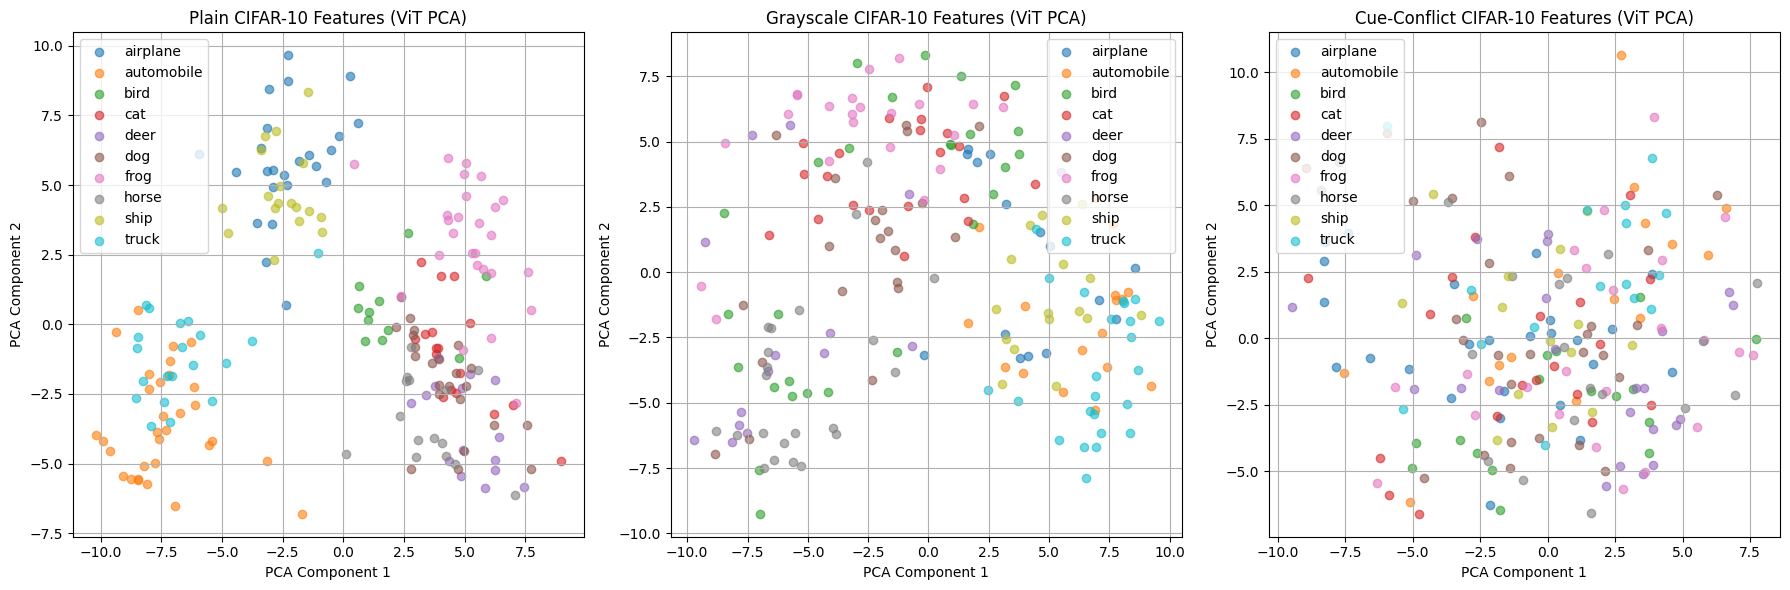

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Get class names for legend (assuming CIFAR-10 classes are the same)
class_names = plain_test_dataset.classes

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Plain CIFAR-10 features (ViT)
for i in range(len(class_names)):
    class_indices = plain_labels_vit == i
    axes[0].scatter(plain_features_reduced_vit[class_indices, 0], plain_features_reduced_vit[class_indices, 1], label=class_names[i], alpha=0.6)
axes[0].set_title("Plain CIFAR-10 Features (ViT PCA)")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].legend()
axes[0].grid(True)

# Plot Grayscale CIFAR-10 features (ViT)
for i in range(len(class_names)):
    class_indices = gs_labels_vit == i
    axes[1].scatter(gs_features_reduced_vit[class_indices, 0], gs_features_reduced_vit[class_indices, 1], label=class_names[i], alpha=0.6)
axes[1].set_title("Grayscale CIFAR-10 Features (ViT PCA)")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
axes[1].legend()
axes[1].grid(True)

# Plot Cue-Conflict CIFAR-10 features (ViT)
for i in range(len(class_names)):
    class_indices = cue_labels_vit == i
    axes[2].scatter(cue_features_reduced_vit[class_indices, 0], cue_features_reduced_vit[class_indices, 1], label=class_names[i], alpha=0.6)
axes[2].set_title("Cue-Conflict CIFAR-10 Features (ViT PCA)")
axes[2].set_xlabel("PCA Component 1")
axes[2].set_ylabel("PCA Component 2")
axes[2].legend()
axes[2].grid(True)

# Adjust layout and display plots
plt.tight_layout()
plt.show()